<a href="https://colab.research.google.com/github/monikaly13/waste-sorting-assistant/blob/main/train_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install transformers datasets torch torchvision accelerate -q

In [8]:
from huggingface_hub import hf_hub_download
import zipfile, os

zip_path = hf_hub_download(
    repo_id="garythung/trashnet",
    filename="dataset-resized.zip",
    repo_type="dataset"
)

extract_dir = "/content/trashnet_data"
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.listdir(extract_dir))

['dataset-resized', '__MACOSX']


In [10]:
print(os.listdir("/content/trashnet_data/dataset-resized"))

['trash', '.DS_Store', 'paper', 'cardboard', 'metal', 'plastic', 'glass']


In [11]:
from datasets import load_dataset

dataset = load_dataset("imagefolder", data_dir="/content/trashnet_data/dataset-resized")
print(dataset)

Resolving data files:   0%|          | 0/2527 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2527
    })
})


In [12]:
print(dataset["train"].features)
print(dataset["train"][0])

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'])}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x384 at 0x7F2BA05E27B0>, 'label': 0}


In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['HF_DATASETS_CACHE'] = '/content/drive/MyDrive/waste-sorting-assistant/hf_cache'

Mounted at /content/drive


In [14]:
from collections import Counter

labels = dataset["train"]["label"]
label_names = dataset["train"].features["label"].names
counts = Counter(labels)

for i, name in enumerate(label_names):
    print(f"{name}: {counts[i]} images")

cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


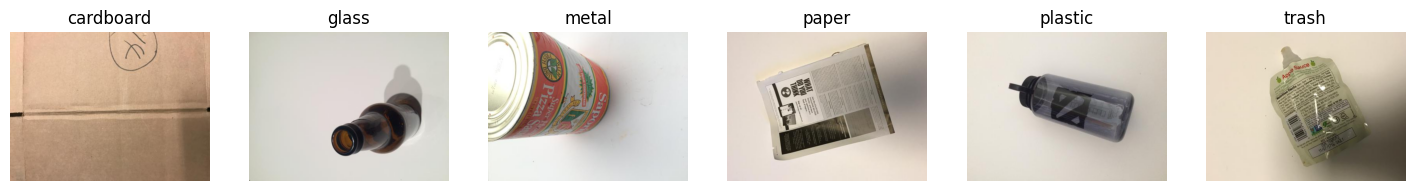

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, name in enumerate(label_names):
    idx = labels.index(i)
    img = dataset["train"][idx]["image"]
    axes[i].imshow(img)
    axes[i].set_title(name)
    axes[i].axis("off")
plt.show()

In [16]:
# Split off 30% for val+test, stratified by label
split1 = dataset["train"].train_test_split(test_size=0.3, seed=42, stratify_by_column="label")

# Split that 30% in half -> 15% val, 15% test
split2 = split1["test"].train_test_split(test_size=0.5, seed=42, stratify_by_column="label")

from datasets import DatasetDict
dataset = DatasetDict({
    "train": split1["train"],
    "validation": split2["train"],
    "test": split2["test"]
})

print(dataset)

# Confirm class balance held up in each split
from collections import Counter
for split_name in ["train", "validation", "test"]:
    print(f"\n{split_name}:")
    split_labels = dataset[split_name]["label"]
    counts = Counter(split_labels)
    for i, name in enumerate(label_names):
        print(f"  {name}: {counts[i]}")

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1768
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 379
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 380
    })
})

train:
  cardboard: 282
  glass: 350
  metal: 287
  paper: 416
  plastic: 337
  trash: 96

validation:
  cardboard: 61
  glass: 75
  metal: 61
  paper: 89
  plastic: 72
  trash: 21

test:
  cardboard: 60
  glass: 76
  metal: 62
  paper: 89
  plastic: 73
  trash: 20


In [17]:
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
    ignore_mismatched_sizes=True  # needed since we're replacing the final layer
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [18]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

dataset = dataset.with_transform(preprocess)

In [19]:
sample = dataset["train"][0]
print(sample["pixel_values"].shape)
print(sample["labels"])

torch.Size([3, 224, 224])
0


In [20]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


In [21]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [22]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit-waste-sorter",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20,
    remove_unused_columns=False,
)

In [24]:
split1 = dataset["train"].train_test_split(test_size=0.3, seed=42, stratify_by_column="label")
split2 = split1["test"].train_test_split(test_size=0.5, seed=42, stratify_by_column="label")

from datasets import DatasetDict
dataset = DatasetDict({
    "train": split1["train"],
    "validation": split2["train"],
    "test": split2["test"]
})

In [25]:
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [26]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

dataset = dataset.with_transform(preprocess)

In [27]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [28]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit-waste-sorter",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20,
    remove_unused_columns=False,
)

In [29]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.563945,0.333561,0.886792
2,0.094080,0.180688,0.939623
3,0.029742,0.148053,0.943396
4,0.003481,0.151136,0.954717
5,0.002486,0.150583,0.954717
6,0.001775,0.155492,0.958491
7,0.001586,0.156629,0.954717
8,0.001412,0.156743,0.958491


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=624, training_loss=0.11751967569505677, metrics={'train_runtime': 534.2894, 'train_samples_per_second': 18.522, 'train_steps_per_second': 1.168, 'total_flos': 7.668882217466266e+17, 'train_loss': 0.11751967569505677, 'epoch': 8.0})

In [30]:
import os

save_path = "/content/drive/MyDrive/waste-sorting-assistant/vit-waste-model"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/waste-sorting-assistant/vit-waste-model


In [31]:
test_results = trainer.evaluate(dataset["test"])
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy
0.001412,0.221921,8,0.932331


{'eval_loss': 0.2219211757183075, 'eval_accuracy': 0.9323308270676691}


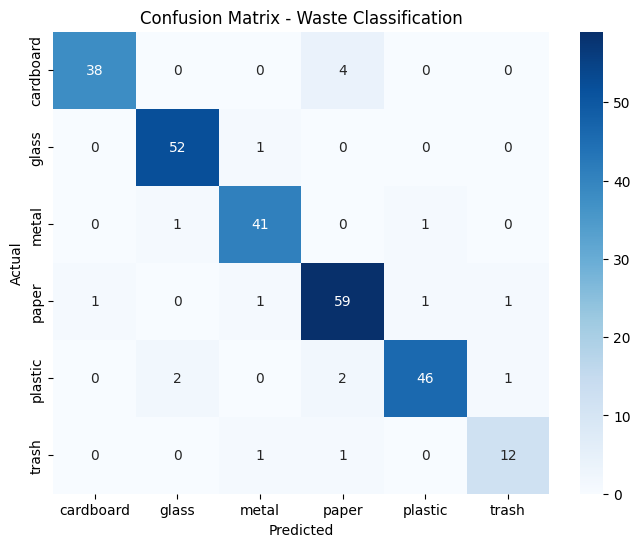

In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on the test set
predictions = trainer.predict(dataset["test"])
preds = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Build confusion matrix
cm = confusion_matrix(true_labels, preds)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Waste Classification")
plt.show()

In [33]:
print(len(dataset["test"]))
print(len(true_labels))

266
266


In [34]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1237
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 265
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 266
    })
})


In [35]:
print(os.listdir("/content/trashnet_data/dataset-resized"))

from datasets import load_dataset
raw = load_dataset("imagefolder", data_dir="/content/trashnet_data/dataset-resized")
print(raw)

['trash', '.DS_Store', 'paper', 'cardboard', 'metal', 'plastic', 'glass']


Resolving data files:   0%|          | 0/2527 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2527
    })
})


In [36]:
label_names = raw["train"].features["label"].names

split1 = raw["train"].train_test_split(test_size=0.3, seed=42, stratify_by_column="label")
split2 = split1["test"].train_test_split(test_size=0.5, seed=42, stratify_by_column="label")

from datasets import DatasetDict
dataset = DatasetDict({
    "train": split1["train"],
    "validation": split2["train"],
    "test": split2["test"]
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1768
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 379
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 380
    })
})


In [37]:
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [38]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

dataset = dataset.with_transform(preprocess)

In [39]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit-waste-sorter-v2",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20,
    remove_unused_columns=False,
)

In [40]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.350529,0.282387,0.910290
2,0.074331,0.149424,0.949868
3,0.010788,0.126553,0.960422
4,0.002879,0.133373,0.957784
5,0.009268,0.131350,0.963061
6,0.014132,0.129769,0.960422
7,0.009948,0.131731,0.960422
8,0.007382,0.134078,0.960422


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=888, training_loss=0.10044662351615156, metrics={'train_runtime': 714.7938, 'train_samples_per_second': 19.788, 'train_steps_per_second': 1.242, 'total_flos': 1.0960859951883878e+18, 'train_loss': 0.10044662351615156, 'epoch': 8.0})

In [41]:
import os

save_path = "/content/drive/MyDrive/waste-sorting-assistant/vit-waste-model-v2"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/waste-sorting-assistant/vit-waste-model-v2


In [42]:
test_results = trainer.evaluate(dataset["test"])
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy
0.007382,0.216675,8,0.944737


{'eval_loss': 0.2166750282049179, 'eval_accuracy': 0.9447368421052632}


380


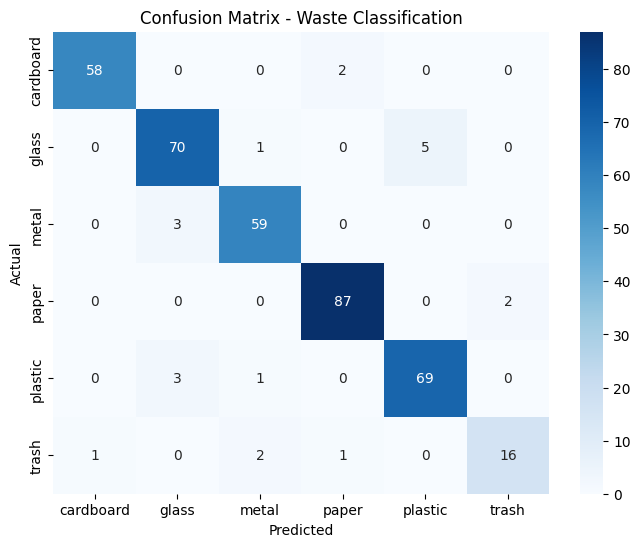

In [43]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(dataset["test"])
preds = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

print(len(true_labels))  # sanity check - should print 380

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Waste Classification")
plt.show()

In [44]:
from PIL import Image
import torch

bin_map = {
    "cardboard": "Recyclable — Blue Bin",
    "glass": "Recyclable — Blue Bin",
    "metal": "Recyclable — Blue Bin",
    "paper": "Recyclable — Blue Bin",
    "plastic": "Recyclable — Blue Bin",
    "trash": "Non-recyclable — General Waste"
}

def predict_waste(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_id = outputs.logits.argmax(-1).item()
    predicted_label = label_names[predicted_class_id]
    confidence = torch.softmax(outputs.logits, dim=-1)[0][predicted_class_id].item()

    print(f"Predicted: {predicted_label} ({confidence:.1%} confidence)")
    print(f"Instruction: {bin_map[predicted_label]}")

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{predicted_label} — {bin_map[predicted_label]}")
    plt.show()

# Example usage — upload an image to Colab first, then:
# predict_waste("/content/your_image.jpg")

In [46]:
from PIL import Image
import torch

bin_map = {
    "cardboard": "Recyclable — Blue Bin",
    "glass": "Recyclable — Blue Bin",
    "metal": "Recyclable — Blue Bin",
    "paper": "Recyclable — Blue Bin",
    "plastic": "Recyclable — Blue Bin",
    "trash": "Non-recyclable — General Waste"
}

device = next(model.parameters()).device  # find out where the model lives

def predict_waste(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}  # move inputs to same device as model

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_id = outputs.logits.argmax(-1).item()
    predicted_label = label_names[predicted_class_id]
    confidence = torch.softmax(outputs.logits, dim=-1)[0][predicted_class_id].item()

    print(f"Predicted: {predicted_label} ({confidence:.1%} confidence)")
    print(f"Instruction: {bin_map[predicted_label]}")

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{predicted_label} — {bin_map[predicted_label]}")
    plt.show()

Predicted: plastic (94.2% confidence)
Instruction: Recyclable — Blue Bin


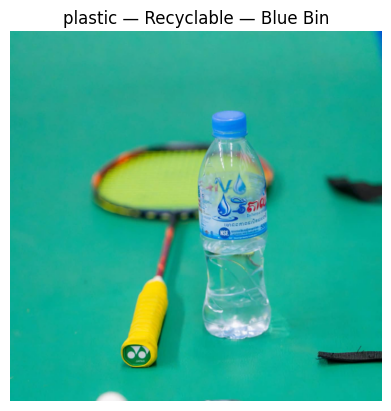

In [47]:
predict_waste("/content/vital.png")

Predicted: plastic (61.2% confidence)
Instruction: Recyclable — Blue Bin


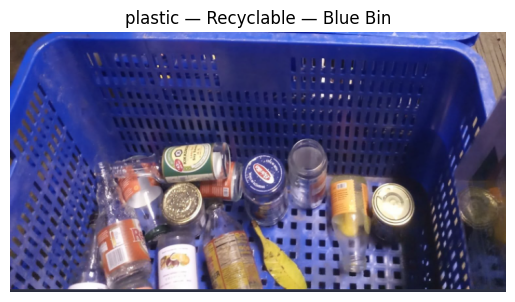

In [49]:
predict_waste("/content/metal.png")

Predicted: metal (87.0% confidence)
Instruction: Recyclable — Blue Bin


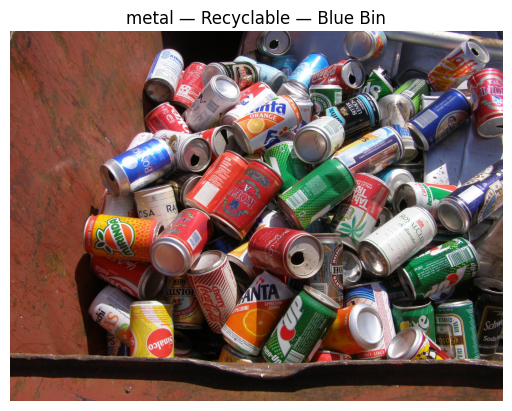

In [51]:
predict_waste("/content/metal#2.jpg")

In [52]:
import os

save_path = "/content/drive/MyDrive/waste-sorting-assistant/vit-waste-model-v2"
print(os.path.exists(save_path))
print(os.listdir(save_path))

True
['config.json', 'model.safetensors', 'training_args.bin', 'preprocessor_config.json']
